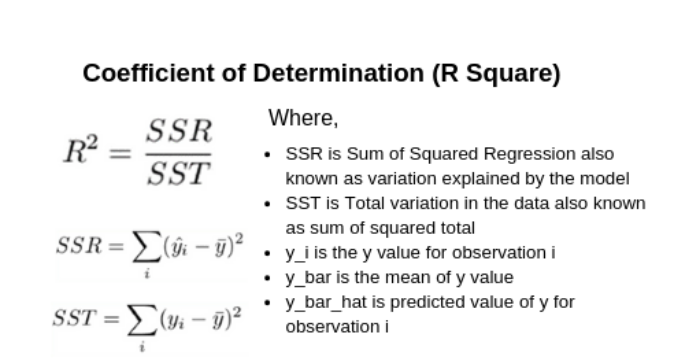

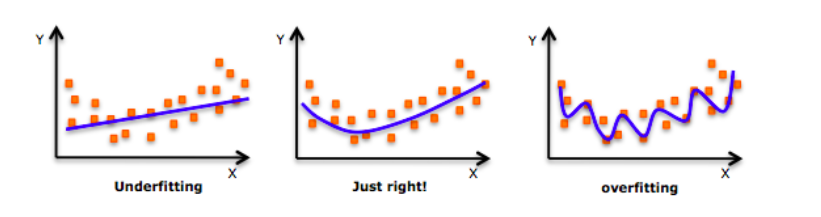

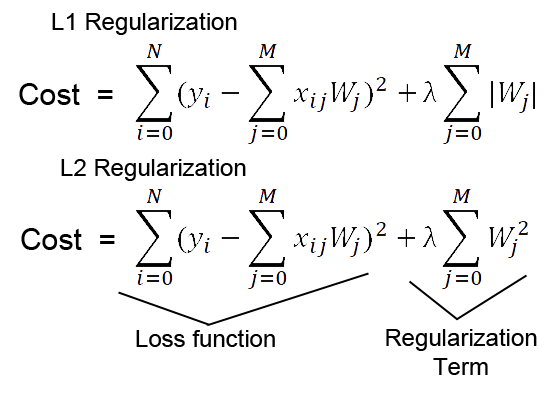

In [ ]:
import pandas as pd

In [ ]:
df=pd.read_csv('/content/housing_multicollinear.csv')

In [ ]:
df.head()

,sqft,num_rooms,age_years,distance_center_km,price_lakhs
0,800,3,15,12,40
1,1200,4,10,9,65
2,1500,5,8,7,78
3,2000,6,5,4,105
4,2500,7,3,2,130


In [ ]:
df.corr()

,sqft,num_rooms,age_years,distance_center_km,price_lakhs
sqft,1.000000,0.979095,-0.928444,-0.967920,0.998466
num_rooms,0.979095,1.000000,-0.915957,-0.947678,0.983811
age_years,-0.928444,-0.915957,1.000000,0.973202,-0.932230
distance_center_km,-0.967920,-0.947678,0.973202,1.000000,-0.967821
price_lakhs,0.998466,0.983811,-0.932230,-0.967821,1.000000


In [ ]:
X=df[['sqft',"num_rooms","age_years",'distance_center_km']]
y=df['price_lakhs']

In [ ]:
from sklearn.model_selection import train_test_split

In [ ]:
X_train, X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=42)

In [ ]:
from sklearn.linear_model import LinearRegression

In [ ]:
baseline=LinearRegression()

In [ ]:
baseline.fit(X_train,y_train)

LinearRegression()

In [ ]:
baseline.score(X_train,y_train)

0.9978343820698663

In [ ]:
baseline.score(X_test,y_test)

0.997904759019552

In [ ]:
for feature,coef in zip(X.columns, baseline.coef_):
  print(f'{feature}: {coef:4f}')

sqft: 0.048707
num_rooms: 2.325408
age_years: -0.309634
distance_center_km: 0.529446


In [ ]:
import numpy as np
for seed in [1,2,3,4,5,6,7,8,9,10]:
  sample=X_train.sample(frac=0.8,random_state=seed)
  y_sample=y_train.loc[sample.index]
  m=LinearRegression().fit(sample,y_sample)
  print(f"seed={seed}:", dict(zip(X.columns,np.round(m.coef_,3))))

seed=1: {'sqft': np.float64(0.045), 'num_rooms': np.float64(2.892), 'age_years': np.float64(-0.047), 'distance_center_km': np.float64(-0.057)}
seed=2: {'sqft': np.float64(0.046), 'num_rooms': np.float64(3.093), 'age_years': np.float64(-0.255), 'distance_center_km': np.float64(0.391)}
seed=3: {'sqft': np.float64(0.048), 'num_rooms': np.float64(2.691), 'age_years': np.float64(0.093), 'distance_center_km': np.float64(-0.043)}
seed=4: {'sqft': np.float64(0.051), 'num_rooms': np.float64(0.865), 'age_years': np.float64(-0.309), 'distance_center_km': np.float64(0.427)}
seed=5: {'sqft': np.float64(0.053), 'num_rooms': np.float64(0.946), 'age_years': np.float64(-0.597), 'distance_center_km': np.float64(1.039)}
seed=6: {'sqft': np.float64(0.05), 'num_rooms': np.float64(1.941), 'age_years': np.float64(-0.046), 'distance_center_km': np.float64(0.143)}
seed=7: {'sqft': np.float64(0.049), 'num_rooms': np.float64(2.404), 'age_years': np.float64(-0.367), 'distance_center_km': np.float64(0.612)}
seed=8

# Ridge

In [ ]:
from sklearn.linear_model import Ridge

In [ ]:
ridge=Ridge(alpha=1000)

In [ ]:
ridge.fit(X_train,y_train)

Ridge(alpha=1000)

In [ ]:
ridge.score(X_test,y_test)

0.9950049243076797

In [ ]:
for feature,coef in zip(X.columns, ridge.coef_):
  print(f'{feature}: {coef:4f}')

sqft: 0.053529
num_rooms: 0.004022
age_years: -0.008054
distance_center_km: 0.000960


In [ ]:
sqft: 0.048707
num_rooms: 2.325408
age_years: -0.309634
distance_center_km: 0.529446

In [ ]:
import numpy as np
for seed in [1,2,3,4,5,6,7,8,9,10]:
  sample=X_train.sample(frac=0.8,random_state=seed)
  y_sample=y_train.loc[sample.index]
  m=Ridge(alpha=100).fit(sample,y_sample)
  print(f"seed={seed}:", dict(zip(X.columns,np.round(m.coef_,3))))

seed=1: {'sqft': np.float64(0.053), 'num_rooms': np.float64(0.031), 'age_years': np.float64(-0.027), 'distance_center_km': np.float64(-0.008)}
seed=2: {'sqft': np.float64(0.053), 'num_rooms': np.float64(0.037), 'age_years': np.float64(-0.027), 'distance_center_km': np.float64(0.021)}
seed=3: {'sqft': np.float64(0.055), 'num_rooms': np.float64(0.034), 'age_years': np.float64(0.042), 'distance_center_km': np.float64(0.029)}
seed=4: {'sqft': np.float64(0.052), 'num_rooms': np.float64(0.011), 'age_years': np.float64(-0.066), 'distance_center_km': np.float64(-0.001)}
seed=5: {'sqft': np.float64(0.053), 'num_rooms': np.float64(0.013), 'age_years': np.float64(-0.084), 'distance_center_km': np.float64(0.026)}
seed=6: {'sqft': np.float64(0.054), 'num_rooms': np.float64(0.028), 'age_years': np.float64(0.026), 'distance_center_km': np.float64(0.017)}
seed=7: {'sqft': np.float64(0.054), 'num_rooms': np.float64(0.031), 'age_years': np.float64(-0.059), 'distance_center_km': np.float64(0.024)}
seed=8

# Lasso

In [ ]:
from sklearn.linear_model import Lasso

In [ ]:
lasso=Lasso(alpha=6)
lasso.fit(X_train,y_train)

Lasso(alpha=6)

In [ ]:
for feature,coef in zip(X.columns, lasso.coef_):
  print(f'{feature}: {coef:4f}')

sqft: 0.053594
num_rooms: 0.000000
age_years: -0.000000
distance_center_km: 0.000000


In [ ]:
for a in [0.001, 0.01,0.1,0.5,2,3]:
  l=Lasso(alpha=a).fit(X_train,y_train)
  print(l.score(X_test,y_test))

0.9978981429266268
0.9978335342532304
0.9966865755293042
0.9949554694161997
0.9949431707353723
0.9949349566857507
